# Chalconatronite — Test sur images choisies + Grad-CAM
### Charge un modèle entraîné (.pth) et l'applique aux images dont vous donnez le chemin

**Ce notebook :**
1. Charge un checkpoint entraîné (MobileNetV2, ResNet-50 ou EfficientNet-B0 — un seul switch à changer)
2. Vous listez simplement les chemins des images à tester dans `IMAGE_PATHS`
3. Pour chaque image : affiche l'image, la prédiction, la confiance, le détail des probabilités, et la visualisation Grad-CAM (zones d'activation)
4. Termine par un tableau récapitulatif de toutes les images testées

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torchvision import transforms, models

print("Imports OK")
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

Imports OK
PyTorch : 2.5.1+cu121
CUDA    : True


## 1 — Configuration

In [ ]:
# =============================================================
# CONFIGURATION 
# =============================================================

# MODEL_ARCH : "mobilenetv2" | "resnet50" | "efficientnet_b0"
MODEL_ARCH = "mobilenetv2"
MODEL_PATH = "best_mobilenetv2.pth"

# Listez ici les chemins des images à tester (autant que vous voulez)
IMAGE_PATHS = [
    "test-1.jpg",
    "test-2.jpg",
]

CLASS_NAMES = ["with_chalconatronite", "without_chalconatronite"]
IMG_SIZE = 224
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

assert os.path.exists(MODEL_PATH), f"Checkpoint introuvable : {MODEL_PATH}"
for p in IMAGE_PATHS:
    assert os.path.exists(p), f"Image introuvable : {p}"
print(f"{len(IMAGE_PATHS)} image(s) prête(s) à être testée(s).")

Device : cuda
2 image(s) prête(s) à être testée(s).


## 2 — Construction du modèle et chargement des poids

In [ ]:
def build_model(arch):
    """
    Reconstruit l'architecture EXACTEMENT comme dans le notebook d'entraînement
    correspondant, puis charge les poids sauvegardés. Si votre tête de
    classification (dropout, nb de couches) diffère de celle ci-dessous pour
    ResNet-50 / EfficientNet-B0, ajustez-la ici pour qu'elle corresponde à
    votre notebook d'entraînement respectif, sinon load_state_dict échouera.
    """
    if arch == "mobilenetv2":
        model = models.mobilenet_v2(weights=None)
        num_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_features, 2))
        target_layer = None  # résolu après création : model.features[-1]

    elif arch == "resnet50":
        model = models.resnet50(weights=None)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_features, 2))
        target_layer = None  # model.layer4[-1]

    elif arch == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        num_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_features, 2))
        target_layer = None  # model.features[-1]

    else:
        raise ValueError(f"Architecture inconnue : {arch}")

    return model


model = build_model(MODEL_ARCH)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

# Couche cible pour Grad-CAM
if MODEL_ARCH in ("mobilenetv2", "efficientnet_b0"):
    gradcam_layer = model.features[-1]
elif MODEL_ARCH == "resnet50":
    gradcam_layer = model.layer4[-1]

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN.tolist(), std=STD.tolist())
])

print(f"Modèle {MODEL_ARCH} chargé depuis {MODEL_PATH}")

C:\Users\CD44\AppData\Local\Temp\ipykernel_29172\2293816208.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)


Modèle mobilenetv2 chargé depuis best_mobilenetv2.pth


## 3 — Grad-CAM (implémentation)

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, target_class]
        score.backward()

        gradients = self.gradients[0]         # [C, H, W]
        activations = self.activations[0]     # [C, H, W]
        weights = gradients.mean(dim=(1, 2))   # [C]

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for c, w in enumerate(weights):
            cam += w * activations[c]

        cam = F.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.cpu().numpy()

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()


gradcam = GradCAM(model, gradcam_layer)
print("Grad-CAM prêt.")

Grad-CAM prêt.


## 4 — Analyse d'une image : prédiction + probabilités + Grad-CAM

In [ ]:
def overlay_gradcam(image_path, cam_map, img_size=IMG_SIZE, alpha=0.45):
    img = Image.open(image_path).convert("RGB").resize((img_size, img_size))
    img_np = np.array(img).astype(np.float32) / 255.0

    cam_img = Image.fromarray((cam_map * 255).astype(np.uint8)).resize((img_size, img_size), Image.BILINEAR)
    cam_resized = np.array(cam_img).astype(np.float32) / 255.0

    heatmap = cm.jet(cam_resized)[:, :, :3]
    overlay = np.clip((1 - alpha) * img_np + alpha * heatmap, 0, 1)
    return img_np, heatmap, overlay


def analyze_image(image_path):
    """Affiche l'image, la prédiction, les probabilités par classe, et la Grad-CAM."""
    img = Image.open(image_path).convert("RGB")
    tensor = eval_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0]
    predicted_class = int(torch.argmax(probs).item())

    cam_map = gradcam.generate(tensor, predicted_class)
    img_np, heatmap, overlay = overlay_gradcam(image_path, cam_map)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_np); axes[0].axis("off"); axes[0].set_title("Original")
    axes[1].imshow(heatmap); axes[1].axis("off"); axes[1].set_title("Grad-CAM")
    axes[2].imshow(overlay); axes[2].axis("off"); axes[2].set_title("Superposé")
    plt.suptitle(f"{os.path.basename(image_path)} — {CLASS_NAMES[predicted_class]} "
                 f"({probs[predicted_class]*100:.1f}%)", fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Fichier      : {image_path}")
    print(f"Prédiction   : {CLASS_NAMES[predicted_class]}")
    print(f"Confiance    : {probs[predicted_class]*100:.2f}%")
    for i, cname in enumerate(CLASS_NAMES):
        print(f"  P({cname}) = {probs[i]*100:.2f}%")
    print("-" * 60)

    return {
        "filepath": image_path,
        "filename": os.path.basename(image_path),
        "predicted_class": CLASS_NAMES[predicted_class],
        "confidence": float(probs[predicted_class]),
        f"prob_{CLASS_NAMES[0]}": float(probs[0]),
        f"prob_{CLASS_NAMES[1]}": float(probs[1]),
    }

## 5 — Lance l'analyse sur toutes les images listées dans IMAGE_PATHS

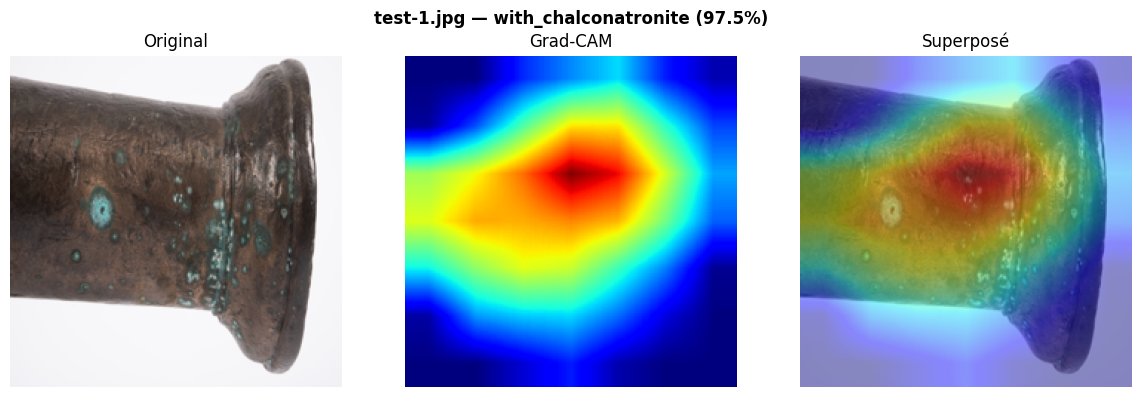

Fichier      : test-1.jpg
Prédiction   : with_chalconatronite
Confiance    : 97.55%
  P(with_chalconatronite) = 97.55%
  P(without_chalconatronite) = 2.45%
------------------------------------------------------------


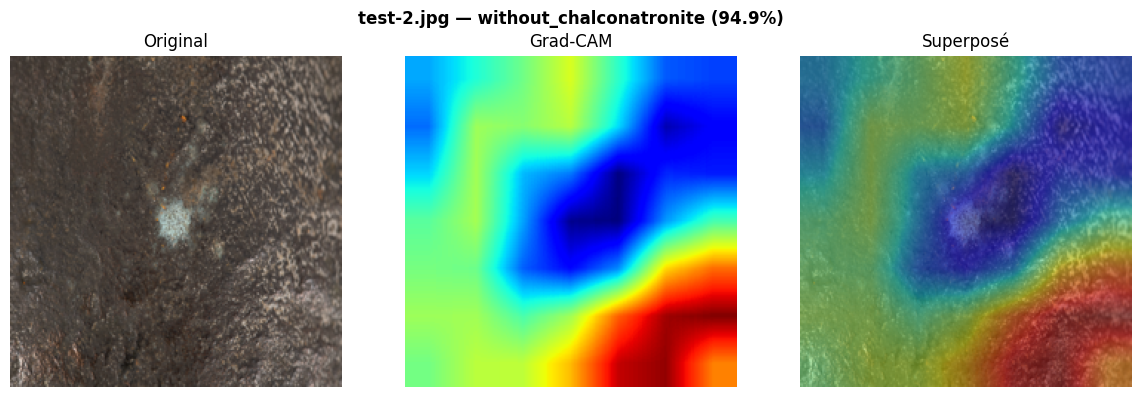

Fichier      : test-2.jpg
Prédiction   : without_chalconatronite
Confiance    : 94.94%
  P(with_chalconatronite) = 5.06%
  P(without_chalconatronite) = 94.94%
------------------------------------------------------------


,filepath,filename,predicted_class,confidence,prob_with_chalconatronite,prob_without_chalconatronite
0,test-1.jpg,test-1.jpg,with_chalconatronite,0.975468,0.975468,0.024532
1,test-2.jpg,test-2.jpg,without_chalconatronite,0.949389,0.050611,0.949389


In [ ]:
results = [analyze_image(p) for p in IMAGE_PATHS]

results_df = pd.DataFrame(results)
results_df

## 6 — Ajouter une image à tester via fct analyse_image

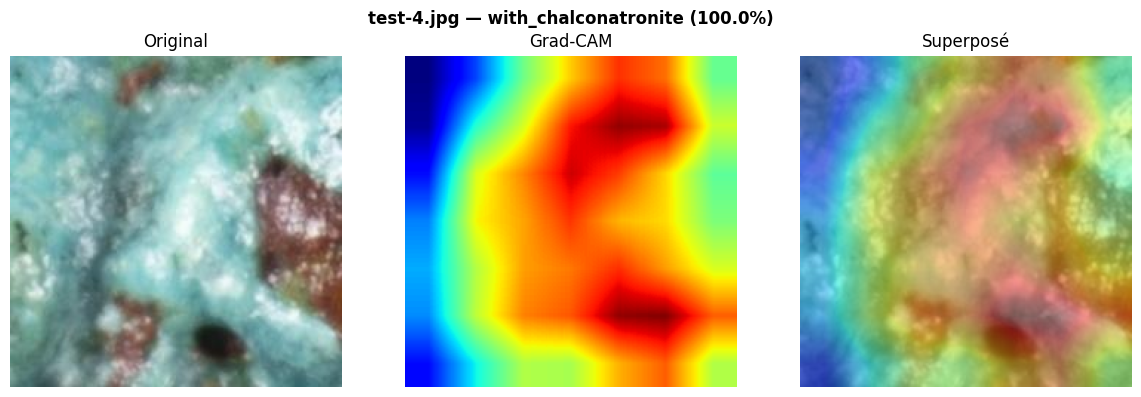

Fichier      : test-4.jpg
Prédiction   : with_chalconatronite
Confiance    : 100.00%
  P(with_chalconatronite) = 100.00%
  P(without_chalconatronite) = 0.00%
------------------------------------------------------------


{'filepath': 'test-4.jpg',
 'filename': 'test-4.jpg',
 'predicted_class': 'with_chalconatronite',
 'confidence': 1.0,
 'prob_with_chalconatronite': 1.0,
 'prob_without_chalconatronite': 1.0265570615786146e-08}

In [ ]:
analyze_image("test-4.jpg")

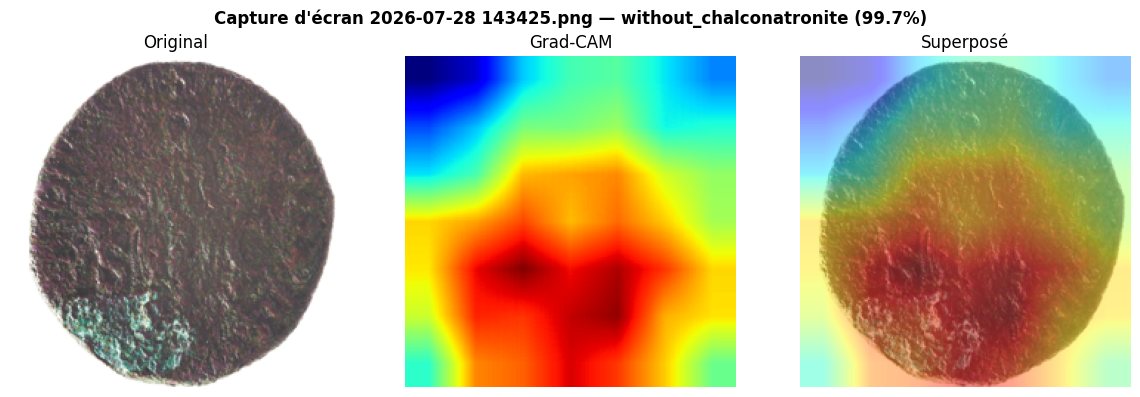

Fichier      : C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143425.png
Prédiction   : without_chalconatronite
Confiance    : 99.70%
  P(with_chalconatronite) = 0.30%
  P(without_chalconatronite) = 99.70%
------------------------------------------------------------


{'filepath': "C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143425.png",
 'filename': "Capture d'écran 2026-07-28 143425.png",
 'predicted_class': 'without_chalconatronite',
 'confidence': 0.9970027804374695,
 'prob_with_chalconatronite': 0.002997230039909482,
 'prob_without_chalconatronite': 0.9970027804374695}

In [ ]:
analyze_image("C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143425.png") #image non chalco

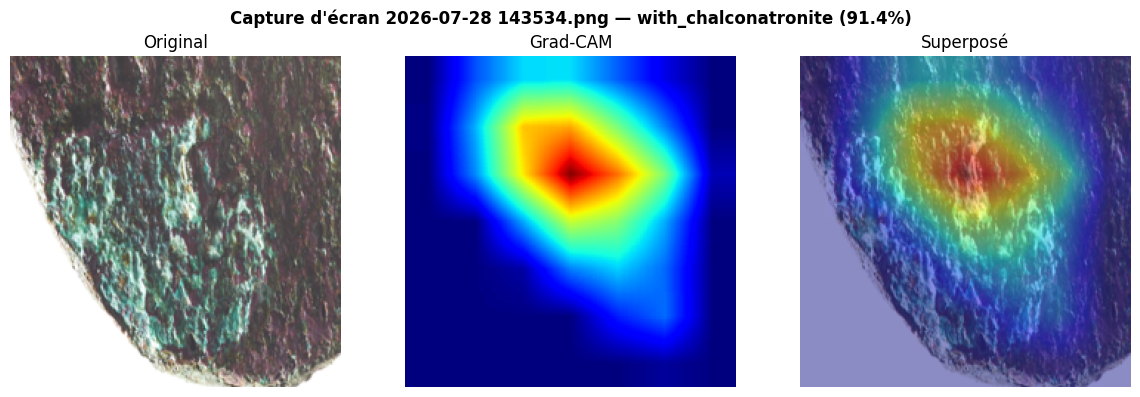

Fichier      : C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143534.png
Prédiction   : with_chalconatronite
Confiance    : 91.43%
  P(with_chalconatronite) = 91.43%
  P(without_chalconatronite) = 8.57%
------------------------------------------------------------


{'filepath': "C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143534.png",
 'filename': "Capture d'écran 2026-07-28 143534.png",
 'predicted_class': 'with_chalconatronite',
 'confidence': 0.914282500743866,
 'prob_with_chalconatronite': 0.914282500743866,
 'prob_without_chalconatronite': 0.08571746200323105}

In [ ]:
analyze_image("C:/Users/CD44/Pictures/Screenshots/Capture d'écran 2026-07-28 143534.png") #image non chalco

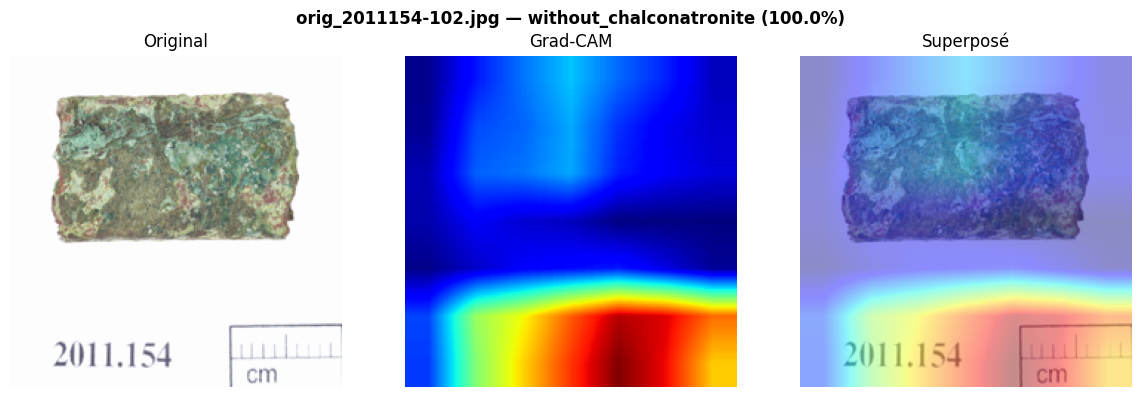

Fichier      : C:/Users/CD44/Desktop/Nouveau dossier/dataset_split/test/without_chalconatronite/orig_2011154-102.jpg
Prédiction   : without_chalconatronite
Confiance    : 100.00%
  P(with_chalconatronite) = 0.00%
  P(without_chalconatronite) = 100.00%
------------------------------------------------------------


{'filepath': 'C:/Users/CD44/Desktop/Nouveau dossier/dataset_split/test/without_chalconatronite/orig_2011154-102.jpg',
 'filename': 'orig_2011154-102.jpg',
 'predicted_class': 'without_chalconatronite',
 'confidence': 0.9999964237213135,
 'prob_with_chalconatronite': 3.5852831388183404e-06,
 'prob_without_chalconatronite': 0.9999964237213135}

In [ ]:
analyze_image( "C:/Users/CD44/Desktop/Nouveau dossier/dataset_split/test/without_chalconatronite/orig_2011154-102.jpg") #image non chalco